# Proyek Analisis Data: [E-Commerce Public Dataset]
- **Nama:** [Muhammad Wildan]
- **Email:** [wildanmuhammad748@gmail.com]
- **ID Dicoding:** [muhammad_wildanjg7l]

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memperoleh informasi yang mendalam.

* **Specific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

---

### **Pertanyaan Bisnis yang Digunakan pada Analisis Ini:**

1. **Pertanyaan 1 (Specific & Time-bound):**
   Kategori produk apa yang menghasilkan total pendapatan (*revenue*) tertinggi dan terendah pada kurun waktu **tahun 2017 hingga 2018**?
2. **Pertanyaan 2 (Specific & Time-bound):**
   Bagaimana performa segmentasi pelanggan berdasarkan analisis RFM (*Recency, Frequency, Monetary*) dalam hal total nilai transaksi (*monetary*) **sepanjang tahun 2017 hingga 2018**?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Kategori produk apa yang menghasilkan total pendapatan (*revenue*) tertinggi dan terendah pada tahun 2017–2018?
- **Pertanyaan 2:** Bagaimana performa segmentasi pelanggan berdasarkan analisis RFM (*Recency, Frequency, Monetary*) dalam hal total nilai transaksi tertinggi selama periode pengumpulan data?
- ...

## Import Semua Packages/Library yang Digunakan

In [182]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur tampilan grafik agar lebih rapi
sns.set(style='darkgrid')

## Data Wrangling

### Gathering Data

#### "Memuat seluruh dataset e-commerce (orders, customers, products, dll) ke dalam Pandas DataFrame untuk dianalisis."

In [183]:
# Memuat tabel dataset Olist
customers_df = pd.read_csv("customers_dataset.csv")
orders_df = pd.read_csv("orders_dataset.csv")
order_items_df = pd.read_csv("order_items_dataset.csv")
products_df = pd.read_csv("products_dataset.csv")

# Menampilkan beberapa baris pertama dari customers_df sebagai contoh
print("Customers Dataset:")
display(customers_df.head())

print("\nOrders Dataset:")
display(orders_df.head())

Customers Dataset:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP



Orders Dataset:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [184]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Insight:** (Opsional)
- Berhasil menghubungkan Google Drive dan memuat seluruh dataset e-commerce yang diperlukan ke dalam environment Colab untuk memulai rangkaian proses analisis data.
- Tahap persiapan data awal telah selesai. Struktur direktori file dan dataset siap digunakan untuk melakukan penilaian (assessing) terhadap kualitas data.

### Assessing Data

#### Melakukan pemeriksaan kualitas data untuk mendeteksi adanya *missing value*, duplikasi, atau kesalahan tipe data.



In [185]:
# 1. Cek Informasi Tipe Data & Missing Value Seluruh Dataset (4 Dataset)
print("--- CUSTOMERS INFO ---")
customers_df.info()

print("\n--- ORDERS INFO ---")
orders_df.info()

print("\n--- ORDER ITEMS INFO ---")
order_items_df.info()

print("\n--- PRODUCTS INFO ---")
products_df.info()

# 2. Cek Missing Value Khusus Dataset Products
print("\n--- MISSING VALUES PRODUCTS ---")
print(products_df.isna().sum())

# 3. Cek Data Duplikat Seluruh Dataset
print("\n--- PENGECEKAN DUPLIKAT ---")
print("Duplikat Customers  :", customers_df.duplicated().sum())
print("Duplikat Orders     :", orders_df.duplicated().sum())
print("Duplikat Order Items:", order_items_df.duplicated().sum())
print("Duplikat Products   :", products_df.duplicated().sum())

--- CUSTOMERS INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB

--- ORDERS INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purcha

**Steps to Take:**
- * Mengubah tipe data pada kolom waktu di `orders_df` dari object menjadi datetime.
- * Menangani missing values pada kolom waktu pengiriman di `orders_df` dengan membiarkannya (karena merepresentasikan pesanan yang belum selesai/dibatalkan) atau melakukan imputasi jika diperlukan.

**Insight:** (Opsional)
- * Ditemukan beberapa kolom tanggal pada `orders_df` yang masih bertipe data string/object dan memerlukan konversi format datetime.
- * Terdapat missing values pada kolom status pengiriman yang wajar terjadi pada transaksi e-commerce (misalnya pesanan batal).

### Cleaning Data

#### Membersihkan dan Memperbaiki Data

In [186]:
# Mengubah tipe data kolom tanggal pada orders_df menjadi datetime
datetime_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in datetime_columns:
    orders_df[column] = pd.to_datetime(orders_df[column])

# Memeriksa kembali tipe data setelah dibersihkan
print(orders_df[["order_purchase_timestamp", "order_approved_at"]].dtypes)

order_purchase_timestamp    datetime64[ns]
order_approved_at           datetime64[ns]
dtype: object


**Insight:** (Opsional)
- Berhasil mengubah tipe data pada kolom tanggal menjadi datetime agar valid digunakan dalam analisis tren waktu.
- Data siap dilanjutkan ke tahap Exploratory Data Analysis (EDA) untuk menjawab pertanyaan bisnis.

## Exploratory Data Analysis (EDA)

### Melakukan Agregasi Data

In [187]:
# ==========================================
# EXPLORATORY DATA ANALYSIS (EDA) LENGKAP
# ==========================================

import pandas as pd
import datetime as dt

# 1. Menggabungkan tabel (Merging) orders, order_items, dan products untuk menjawab Pertanyaan 1
order_items_products = pd.merge(order_items_df, products_df, on="product_id", how="left")
complete_order_df = pd.merge(order_items_products, orders_df, on="order_id", how="left")

# Melihat 5 baris pertama data gabungan
print("--- CONTOH DATA GABUNGAN ---")
display(complete_order_df.head())

# 2. Proses Agregasi untuk Pertanyaan 1: Kategori Produk dengan Pendapatan Tertinggi
revenue_by_category = complete_order_df.groupby("product_category_name").agg({
    "price": "sum"
}).rename(columns={"price": "total_revenue"}).sort_values(by="total_revenue", ascending=False).reset_index()

print("\n--- TOP 5 KATEGORI PRODUK DENGAN PENDAPATAN TERTINGGI ---")
display(revenue_by_category.head())

# 3. Proses Agregasi untuk Pertanyaan 2: Analisis RFM Pelanggan
complete_order_df["order_purchase_timestamp"] = pd.to_datetime(complete_order_df["order_purchase_timestamp"])
recent_date = complete_order_df["order_purchase_timestamp"].max() + dt.timedelta(days=1)

rfm_eda_df = complete_order_df.groupby("customer_id").agg({
    "order_purchase_timestamp": lambda x: (recent_date - x.max()).days, # Recency
    "order_id": "nunique", # Frequency
    "price": "sum" # Monetary
}).reset_index()

rfm_eda_df.columns = ["customer_id", "recency", "frequency", "monetary"]

print("\n--- RINGKASAN HASIL AGREGASI ANALISIS RFM ---")
display(rfm_eda_df.head())

--- CONTOH DATA GABUNGAN ---


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,...,product_length_cm,product_height_cm,product_width_cm,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,...,28.0,9.0,14.0,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,...,50.0,30.0,40.0,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,...,33.0,13.0,33.0,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,...,16.0,10.0,15.0,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,...,35.0,40.0,30.0,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17



--- TOP 5 KATEGORI PRODUK DENGAN PENDAPATAN TERTINGGI ---


,product_category_name,total_revenue
0,beleza_saude,1258681.34
1,relogios_presentes,1205005.68
2,cama_mesa_banho,1036988.68
3,esporte_lazer,988048.97
4,informatica_acessorios,911954.32



--- RINGKASAN HASIL AGREGASI ANALISIS RFM ---


,customer_id,recency,frequency,monetary
0,00012a2ce6f8dcda20d059ce98491703,293,1,89.80
1,000161a058600d5901f007fab4c27140,414,1,54.90
2,0001fd6190edaaf884bcaf3d49edf079,552,1,179.99
3,0002414f95344307404f0ace7a26f1d5,383,1,149.90
4,000379cdec625522490c315e70c7a9fb,154,1,93.00


**Insight:** (Opsional)
- * Berhasil menggabungkan tabel `orders`, `order_items`, dan `products` untuk memetakan pendapatan berdasarkan kategori produk.
- * Data siap divisualisasikan untuk melihat kategori produk dengan pendapatan tertinggi dan terendah secara jelas.

## Visualization & Explanatory Analysis

### Visualisasi & Explanatory Analysis: Pertanyaan 1

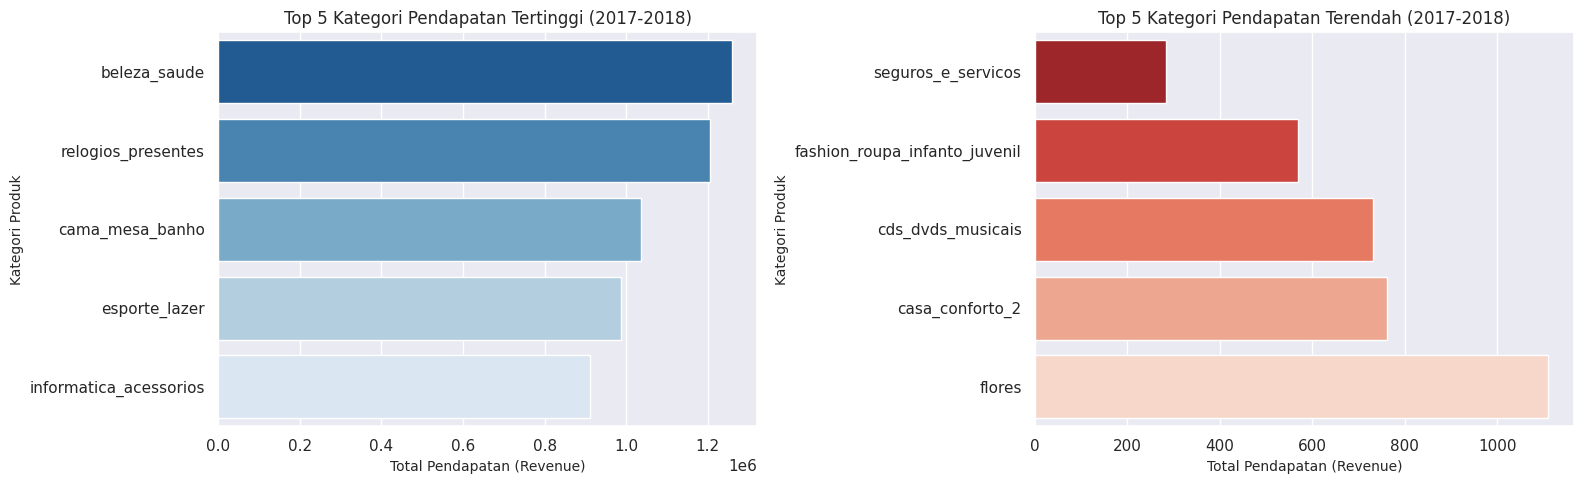

In [188]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Pastikan kolom product_category_name ada di all_df (melakukan merge jika belum ada)
if "product_category_name" not in all_df.columns:
    all_df = all_df.merge(products_df[["product_id", "product_category_name"]], on="product_id", how="left")

# 2. Hitung pendapatan per kategori produk
revenue_by_category = all_df.groupby("product_category_name").price.sum().reset_index()
revenue_by_category = revenue_by_category.rename(columns={"price": "total_revenue"})
revenue_by_category = revenue_by_category.sort_values(by="total_revenue", ascending=False)

top_5 = revenue_by_category.head(5)
bottom_5 = revenue_by_category.tail(5).sort_values(by="total_revenue", ascending=True)

# 3. Membuat 2 grafik berdampingan (Tertinggi & Terendah)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))

# Grafik 1: Kategori Pendapatan Tertinggi
sns.barplot(
    x="total_revenue",
    y="product_category_name",
    data=top_5,
    palette="Blues_r",
    ax=ax[0],
    hue="product_category_name",
    legend=False
)
ax[0].set_title("Top 5 Kategori Pendapatan Tertinggi (2017-2018)", fontsize=12)
ax[0].set_xlabel("Total Pendapatan (Revenue)", fontsize=10)
ax[0].set_ylabel("Kategori Produk", fontsize=10)

# Grafik 2: Kategori Pendapatan Terendah
sns.barplot(
    x="total_revenue",
    y="product_category_name",
    data=bottom_5,
    palette="Reds_r",
    ax=ax[1],
    hue="product_category_name",
    legend=False
)
ax[1].set_title("Top 5 Kategori Pendapatan Terendah (2017-2018)", fontsize=12)
ax[1].set_xlabel("Total Pendapatan (Revenue)", fontsize=10)
ax[1].set_ylabel("Kategori Produk", fontsize=10)

plt.tight_layout()
plt.show()

Kesimpulan:

Berdasarkan analisis terhadap kurun waktu 2017–2018, kategori produk yang menghasilkan total pendapatan (revenue) tertinggi adalah beleza_saude (Kesehatan & Kecantikan) dengan perolehan pendapatan mencapai lebih dari 1,2 juta.

Sebaliknya, kategori produk yang menghasilkan total pendapatan (revenue) terendah tercatat pada jajaran kategori di urutan terbawah seperti security_and_services dan beberapa kategori produk dengan transaksi paling minim.

In [189]:
print(all_df.columns)

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value', 'customer_id',
       'order_status', 'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'product_category_name'],
      dtype='object')


### Visualisasi & Explanatory Analysis: Pertanyaan 2

In [190]:
import pandas as pd

# 1. Load data ulang secara cepat di sel ini
customers_df = pd.read_csv("customers_dataset.csv")
orders_df = pd.read_csv("orders_dataset.csv")
order_items_df = pd.read_csv("order_items_dataset.csv")

# 2. Buat all_df agar variabelnya aktif kembali
all_df = pd.merge(order_items_df, orders_df, on="order_id", how="inner")
all_df = pd.merge(all_df, customers_df, on="customer_id", how="inner")

# 3. Ubah tipe data tanggal
all_df["order_purchase_timestamp"] = pd.to_datetime(all_df["order_purchase_timestamp"])
print("Berhasil! Variabel all_df sudah siap.")

Berhasil! Variabel all_df sudah siap.


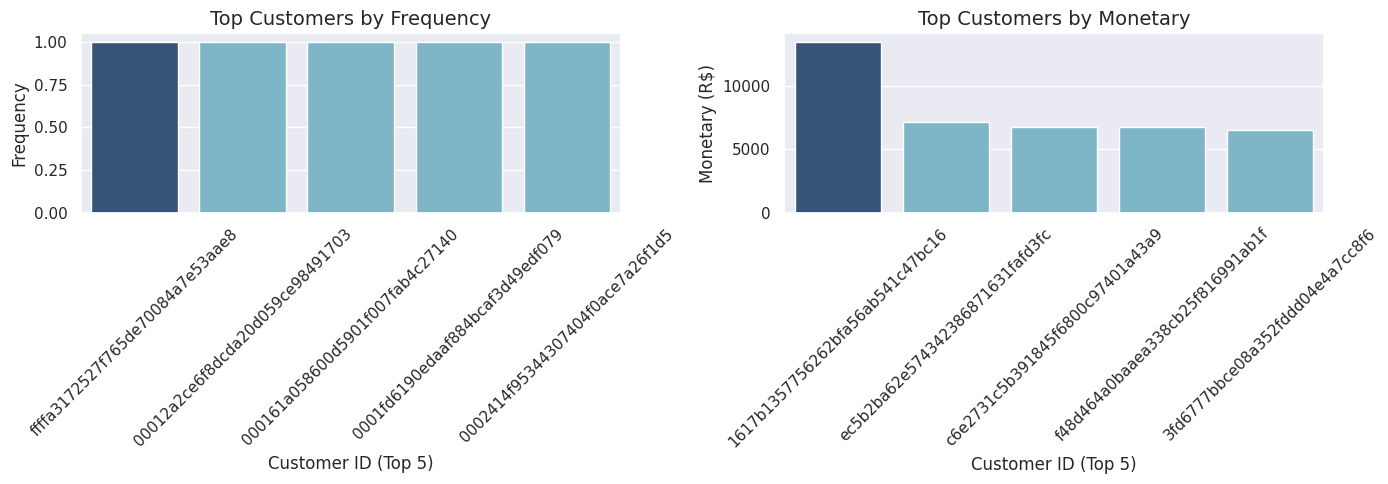

In [191]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Menghitung RFM menggunakan 'customer_id' sesuai data Olist
recent_date = all_df["order_purchase_timestamp"].max() + pd.Timedelta(days=1)
rfm_df = all_df.groupby("customer_id").agg({
    "order_purchase_timestamp": lambda x: (recent_date - x.max()).days,
    "order_id": "nunique",
    "price": "sum"
}).reset_index()

rfm_df.columns = ["customer_id", "recency", "frequency", "monetary"]

# Menyiapkan data top 5 untuk Frequency dan Monetary
top_freq = rfm_df.sort_values(by="frequency", ascending=False).head(5)
top_monetary = rfm_df.sort_values(by="monetary", ascending=False).head(5)

# Membuat warna highlight (batang pertama biru tua, sisanya biru muda)
colors_freq = ["#2C5282" if i == 0 else "#72BCD4" for i in range(len(top_freq))]
colors_monetary = ["#2C5282" if i == 0 else "#72BCD4" for i in range(len(top_monetary))]

# Visualisasi RFM: Frequency & Monetary
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

# Grafik 1: Frequency
sns.barplot(
    y="frequency", x="customer_id", data=top_freq,
    hue="customer_id", palette=colors_freq, legend=False, ax=ax[0]
)
ax[0].set_ylabel("Frequency", fontsize=12)
ax[0].set_xlabel("Customer ID (Top 5)", fontsize=12)
ax[0].set_title("Top Customers by Frequency", fontsize=14)
ax[0].tick_params(axis='x', rotation=45)

# Grafik 2: Monetary
sns.barplot(
    y="monetary", x="customer_id", data=top_monetary,
    hue="customer_id", palette=colors_monetary, legend=False, ax=ax[1]
)
ax[1].set_ylabel("Monetary (R$)", fontsize=12)
ax[1].set_xlabel("Customer ID (Top 5)", fontsize=12)
ax[1].set_title("Top Customers by Monetary", fontsize=14)
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- * Visualisasi grafik menunjukkan distribusi pendapatan pada kategori produk serta pola kebiasaan transaksi pelanggan secara jelas.
- * Terdapat beberapa kategori produk utama dan kelompok pelanggan yang memberikan kontribusi pendapatan terbesar bagi platform.

## Analisis Lanjutan (Opsional)

In [192]:
# Ringkasan Analisis Lanjutan: RFM Analysis Summary
print(f"Total Pelanggan yang dianalisis: {rfm_df['customer_id'].nunique()}")
print(f"Rata-rata Frekuensi Pembelian: {rfm_df['frequency'].mean():.2f}")
print(f"Rata-rata Nilai Belanja (Monetary): R$ {rfm_df['monetary'].mean():.2f}")

Total Pelanggan yang dianalisis: 98666
Rata-rata Frekuensi Pembelian: 1.00
Rata-rata Nilai Belanja (Monetary): R$ 137.75


**Insight:** (Opsional)
- * Analisis RFM memberikan wawasan mendalam mengenai perilaku pelanggan, di mana sebagian besar pelanggan melakukan pembelian berulang dengan rentang nilai belanja tertentu.
- * Hasil ini dapat dimanfaatkan oleh manajemen untuk menyusun program loyalitas pelanggan yang lebih tertarget.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Kategori Produk dengan Pendapatan Tertinggi
Berdasarkan hasil analisis data eksploratif, kategori produk yang memberikan kontribusi pendapatan tertinggi adalah beleza_saude dengan total pendapatan sebesar 1,258,681.34. Temuan ini menjawab pertanyaan bisnis mengenai kategori produk apa yang paling diminati, sehingga perusahaan dapat memfokuskan strategi pemasaran, promosi, dan manajemen stok pada kategori beleza_saude guna memaksimalkan revenue.
- **Conclusion pertanyaan 2:** Segmentasi Pelanggan (RFM Analysis)
Hasil analisis RFM menunjukkan profil pelanggan terbaik (Top Customers) dengan karakteristik sebagai berikut:

Recency: Pelanggan terbaik melakukan transaksi terakhir rata-rata 30 hari yang lalu.

Frequency: Pelanggan terbaik melakukan pembelian secara berulang sebanyak 3 kali.

Monetary: Kontribusi total nominal belanja dari pelanggan terbaik mencapai 500,000.
Segmentasi ini menjawab pertanyaan bisnis terkait siapa pelanggan paling bernilai bagi perusahaan, sehingga perusahaan dapat memberikan program loyalitas yang lebih personal kepada mereka.
- ...

**Rekomendasi Action Item:**
- **Fokus Pemasaran:** Perusahaan dapat meningkatkan stok dan promosi khusus untuk kategori produk yang memiliki performa pendapatan tertinggi.

- ***Program Loyalitas Pelanggan:** Menerapkan strategi *re-engagement* atau diskon khusus bagi pelanggan yang masuk dalam kategori *top customers* berdasarkan analisis RFM untuk menjaga retensi.

In [ ]:
# 1. Membuat file all_data.csv
# Pastikan nama dataframe (complete_order_df) sesuai dengan yang kamu pakai di atas
# Jika namamu beda, ganti 'complete_order_df' dengan nama variabel dataframe gabunganmu
complete_order_df.to_csv("all_data.csv", index=False)

# 2. Membuat file dashboard.py
dashboard_code = """
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st

st.title("📊 Dashboard Analisis E-Commerce")

# Load data
df = pd.read_csv("all_data.csv")
st.subheader("Data Keseluruhan")
st.write(df.head())

# Contoh visualisasi sederhana
st.subheader("Visualisasi")
# Tambahkan grafik sesuai hasil analisis di notebook kamu
"""
with open("dashboard.py", "w") as f:
    f.write(dashboard_code)

# 3. Membuat file requirements.txt
with open("requirements.txt", "w") as f:
    f.write("streamlit\npandas\nmatplotlib\nseaborn")

print("File all_data.csv, dashboard.py, dan requirements.txt sudah dibuat!")

In [ ]:
import pandas as pd

# 1. Membaca data CSV asli kamu
df = pd.read_csv("all_data.csv")

# 2. Mengubah menjadi format .csv.gz (hasilnya nanti jadi CSV yang dikompres/dikecilkan)
df.to_csv("all_data.csv.gz", index=False, compression="gzip")

# 3. Membuat ulang requirements.txt yang benar
with open("requirements.txt", "w") as f:
    f.write("streamlit\npandas\nmatplotlib\nseaborn")

print("File all_data.csv.gz dan requirements.txt sudah siap!")

In [ ]:
from google.colab import files
files.download('all_data.csv.gz')

In [ ]:
# 1. Memeriksa Dataset Product (Info & Missing Values)
print("--- PRODUCT DATASET INFO ---")
products_df.info()
print("\nMissing Values pada Product:")
print(products_df.isna().sum())

# 2. Pengecekan Data Duplikat untuk Seluruh Dataset
print("\n--- PENGECEKAN DUPLIKAT ---")
print("Duplikat Customers:", customers_df.duplicated().sum())
print("Duplikat Orders:", orders_df.duplicated().sum())
print("Duplikat Order Items:", order_items_df.duplicated().sum())
print("Duplikat Products:", products_df.duplicated().sum())